In [2]:
import pandas as pd
import numpy as np
import plotly.express as px

print("Environment working")

Environment working


In [9]:
import os
print(os.getcwd())

C:\Users\black\OneDrive\Documents\Job search\Python\energy-forecast


In [13]:
df = pd.read_csv('data/demanddata_2024.csv')
#print(df.shape)
#print(df.head())
#print(df.dtypes)


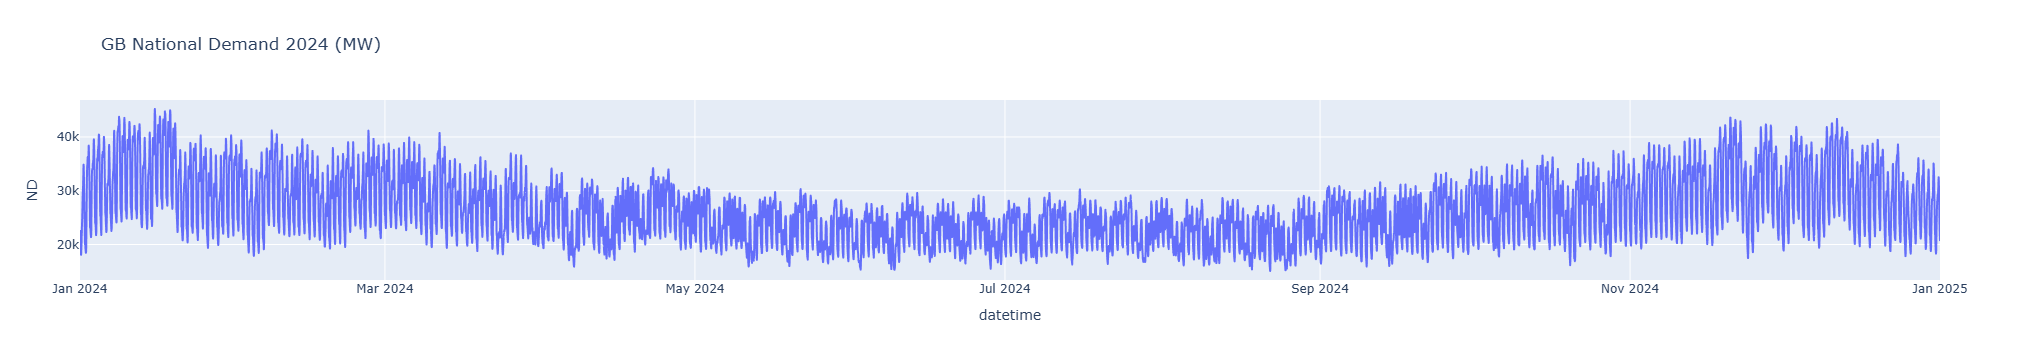

In [23]:
# Parse the date and create a proper datetime index
df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'], format='%d-%b-%Y')

# Create a single datetime column combining date and settlement period
# Each period is 30 minutes, period 1 starts at 00:00
df['datetime'] = df['SETTLEMENT_DATE'] + pd.to_timedelta((df['SETTLEMENT_PERIOD'] - 1) * 30, unit='m')

df = df.set_index('datetime')
df = df.sort_index()

# Quick plot of National Demand
import plotly.express as px

fig = px.line(df, y='ND', title='GB National Demand 2024 (MW)')
fig.show()

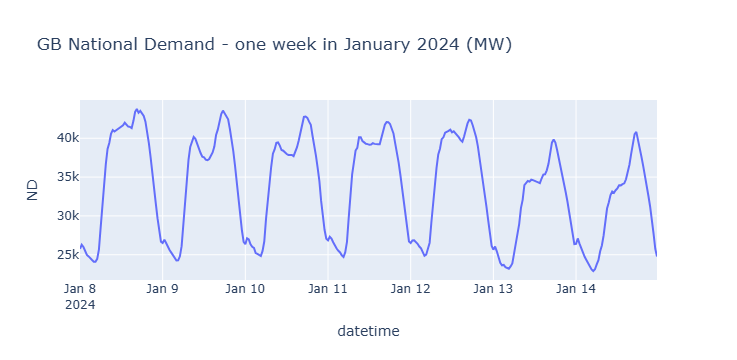

In [26]:
# Plot just one week to see the daily shape clearly
#print(df.head())
one_week = df['2024-01-08':'2024-01-14']

fig = px.line(one_week, y='ND', title='GB National Demand - one week in January 2024 (MW)')
fig.show();

In [39]:

# Adding indexs for hour, day of week, month, and boolean for weekend day
df['hour'] = df.index.hour
df['day_of_week'] = df.index.day_of_week
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'] >= 5



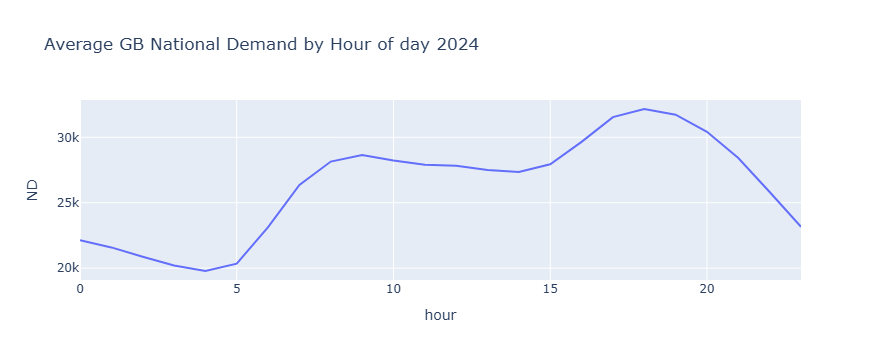

is_weekend
False    12578
True      4990
Name: count, dtype: int64
False
True


In [40]:
hourly_average = df.groupby('hour').ND.mean()

fig = px.line(hourly_average, y='ND', title='Average GB National Demand by Hour of day 2024')
fig.show()


# Check value counts - should be roughly 2/7 True, 5/7 False
print(df['is_weekend'].value_counts())

# Check a specific date you know - 1st Jan 2024 was a Monday
print(df.loc['2024-01-01', 'is_weekend'].iloc[0])  # should be False

# Check a weekend date - 6th Jan 2024 was a Saturday  
print(df.loc['2024-01-06', 'is_weekend'].iloc[0])  # should be True


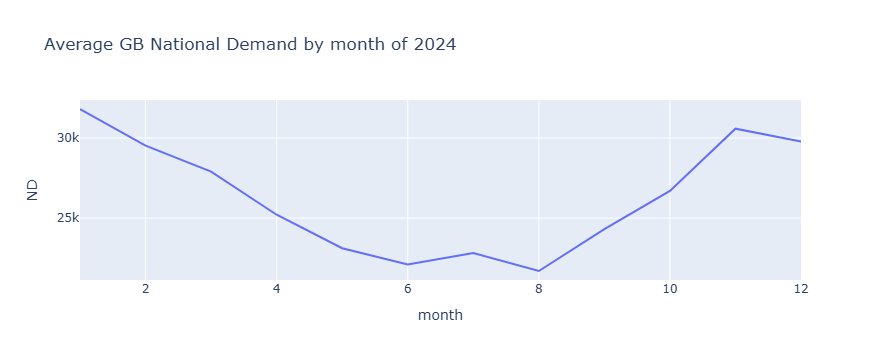

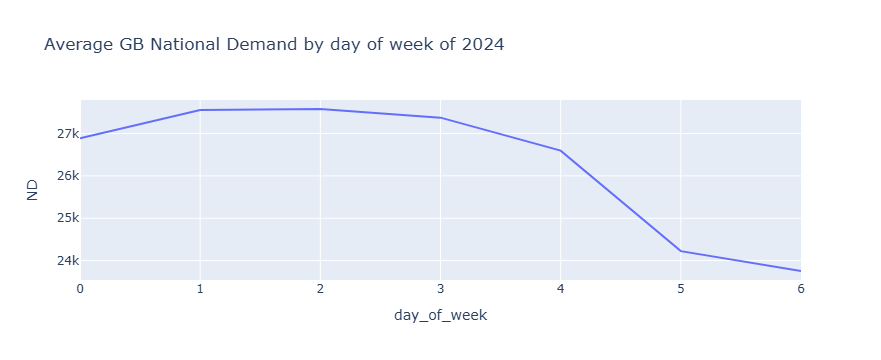

In [41]:
# Visualising average monthly, day of week demand

monthly_average = df.groupby('month').ND.mean()
day_of_week_average = df.groupby('day_of_week').ND.mean()

fig1 = px.line(monthly_average, y='ND', title='Average GB National Demand by month of 2024')
fig2 = px.line(day_of_week_average, y='ND', title='Average GB National Demand by day of week of 2024')
fig1.show()
fig2.show()




In [42]:
print(df.head())

                    SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  \
datetime                                                               
2024-01-01 00:00:00      2024-01-01                  1  21783  23466   
2024-01-01 00:30:00      2024-01-01                  2  22521  24103   
2024-01-01 01:00:00      2024-01-01                  3  22194  24754   
2024-01-01 01:30:00      2024-01-01                  4  21510  24505   
2024-01-01 02:00:00      2024-01-01                  5  20619  23977   

                     ENGLAND_WALES_DEMAND  EMBEDDED_WIND_GENERATION  \
datetime                                                              
2024-01-01 00:00:00                 19539                      2804   
2024-01-01 00:30:00                 20286                      2834   
2024-01-01 01:00:00                 20070                      2868   
2024-01-01 01:30:00                 19424                      2901   
2024-01-01 02:00:00                 18674                      2933  